**Table of contents**<a id='toc0_'></a>    
- [Question 1 - Data Analysis](#toc1_)    
  - [i) Counting Examples](#toc1_1_)    
  - [ii) Protein Expression Histograms](#toc1_2_)    
  - [iii) Image preprocessing](#toc1_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [2]:
!pip install tqdm # for progress bars
!pip install seaborn # for barplot

# <a id='toc1_'></a>[Question 1 - Data Analysis](#toc0_)

## <a id='toc1_1_'></a>[i) Counting Examples](#toc0_)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv('https://warwick.ac.uk/fac/sci/dcs/teaching/material/cs909/protein_expression_data.csv')

df['specimen_id']=df.VisSpot.apply(lambda x: x.split('-')[2]) #create specimen id field
df['image_id']=df.VisSpot.apply(lambda x: x.split('-')[2])+'_'+df.id #create image id field
train_specimens = ['B1', 'C1', 'D1']
df = df.set_index('image_id').sort_index()
protein_names = ['SMAa', 'CD11b',
       'CD44', 'CD31', 'CDK4', 'YKL40', 'CD11c', 'HIF1a', 'CD24', 'TMEM119',
       'OLIG2', 'GFAP', 'VISTA', 'IBA1', 'CD206', 'PTEN', 'NESTIN', 'TCIRG1',
       'CD74', 'MET', 'P2RY12', 'CD163', 'S100B', 'cMYC', 'pERK', 'EGFR',
       'SOX2', 'HLADR', 'PDGFRa', 'MCT4', 'DNA1', 'DNA3', 'MHCI', 'CD68',
       'CD14', 'KI67', 'CD16', 'SOX10']

Let's first separate the training and test data. 

In [4]:
df_train = df.loc[df['specimen_id'].isin(train_specimens)]
df_test = df.loc[df['specimen_id'] == 'A1']

The number of spots of each specimen in the training set are given below:

In [5]:
df_train.groupby('specimen_id')['specimen_id'].value_counts()

specimen_id
B1    1145
C1    4129
D1    1753
Name: count, dtype: int64

## <a id='toc1_2_'></a>[ii) Protein Expression Histograms](#toc0_)

Text(0.5, 0.98, 'CD11b Expression Values by Specimen')

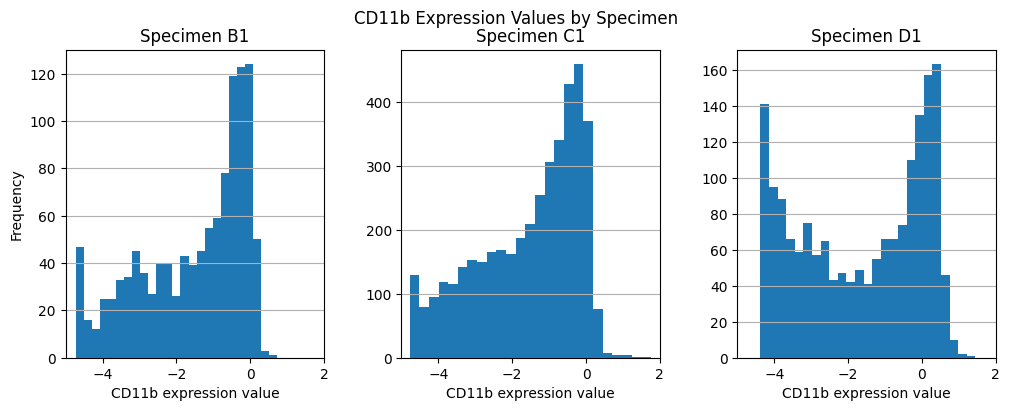

In [6]:
fig, axes = plt.subplots(1, 3)
fig.set_figheight(4)
fig.set_figwidth(12)

for i, ax in enumerate(axes.flatten()):
    specimen = train_specimens[i]
    df_train.loc[df_train['specimen_id'] == specimen].hist('CD11b', ax=ax, bins=25)
    ax.set_title(f"Specimen {specimen}")

    ax.set_xlabel('CD11b expression value')
    if (i == 0):
        ax.set_ylabel('Frequency')
    ax.set_xlim((-5, 2))
    #ax.set_ylim((0, 1050)) # If we want all histograms to be on the same scale
    ax.grid(visible=False, axis='x')
    
fig.suptitle('CD11b Expression Values by Specimen')


We notice that specimen B1 and C1 have similar distributions of the expression value of protein CD11b, with peaks at around 0 and tails to the left down to -5. Specimen D1 has two peaks at -4 and 0. 

Text(0.5, 0.98, 'CD11b Expression Values by Specimen')

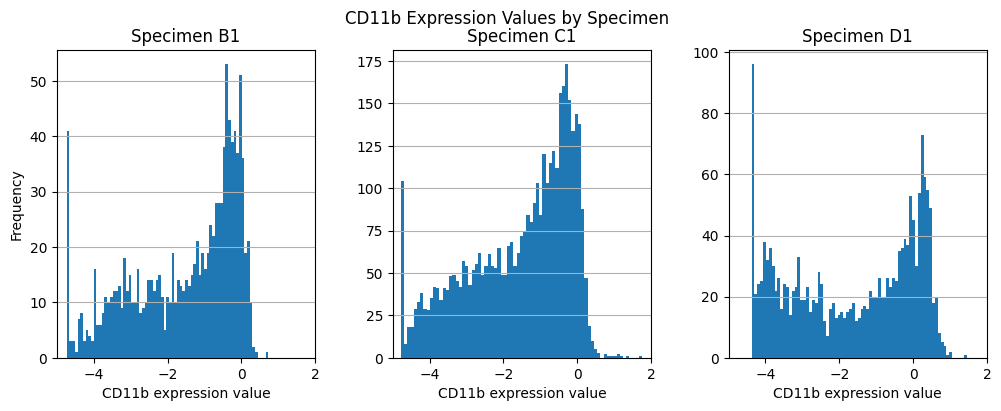

In [7]:
fig, axes = plt.subplots(1, 3)
fig.set_figheight(4)
fig.set_figwidth(12)

for i, ax in enumerate(axes.flatten()):
    specimen = train_specimens[i]
    df_train.loc[df_train['specimen_id'] == specimen].hist('CD11b', ax=ax, bins=75)
    ax.set_title(f"Specimen {specimen}")

    ax.set_xlabel('CD11b expression value')
    if (i == 0):
        ax.set_ylabel('Frequency')
    ax.set_xlim((-5, 2))
    #ax.set_ylim((0, 1050)) # If we want all histograms to be on the same scale
    ax.grid(visible=False, axis='x')
    
fig.suptitle('CD11b Expression Values by Specimen')

If we plot using more bins, we also notice that all three specimen have a peak at a very specific value on the left. This is interesting because there appear to be no expression values to the left of these peaks. 

In [8]:
df_train[['specimen_id', 'CD11b']].value_counts()

specimen_id  CD11b    
C1           -4.782092    104
D1           -4.376121     90
B1           -4.731601     40
C1           -4.402024      2
             -0.155368      1
                         ... 
             -2.256882      1
             -2.259379      1
             -2.261223      1
             -2.261946      1
             -2.240232      1
Name: count, Length: 6795, dtype: int64

We can see the peaks in the above value counts. The frequency peaks are at very specific values, whereas all (except one) other values have a frequency of 1. Plus, there are no values below the peaks. One possible explanation for this suggests that maybe originally there were values below the peaks, but they were for some reason all grouped into that one peak value. 

## <a id='toc1_3_'></a>[iii) Image Preprocessing](#toc0_)

In [21]:
image_folder = '/content/patches_256/'
from skimage.color import rgb2hed
import skimage
from skimage.io import imread
from skimage.color import rgba2rgb
import matplotlib.pyplot as plt
import os
import glob

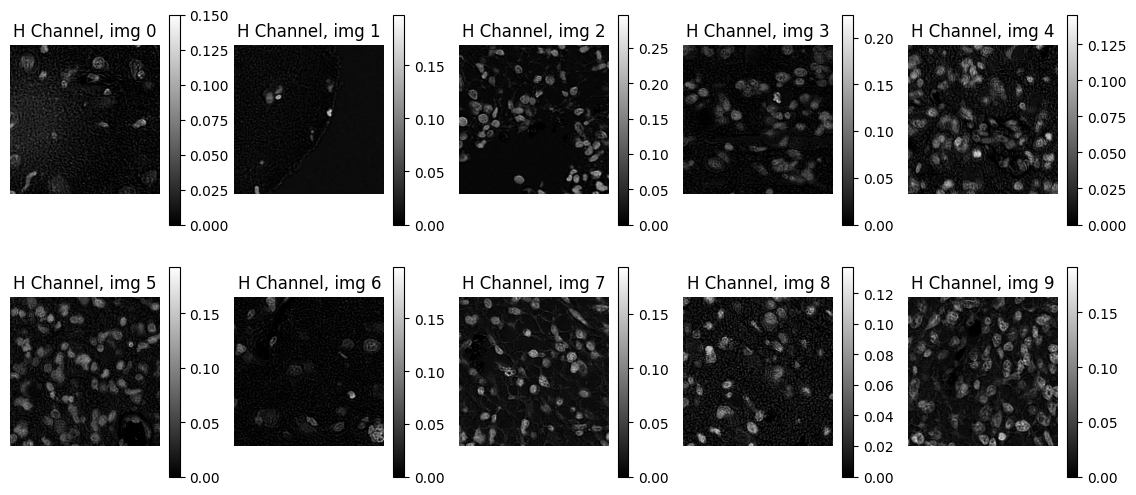

In [10]:
training_image_paths = glob.glob(os.getcwd()+image_folder+'[BCD]*.png')

# We'll use 10 random images
random_indices = np.random.choice(range(len(training_image_paths)), size=10, replace=False)
plt.figure(figsize=[14, 6])
for i, index in enumerate(random_indices):
    I = imread(training_image_paths[i])
    if I.shape[2] == 4: # It's an RGBA image
        I = rgba2rgb(I)
    I_hed = rgb2hed(I)
    I_h = I_hed[:,:,0]; 
    plt.subplot(2, 5, i+1)
    plt.imshow(I_h,cmap='gray');  
    plt.colorbar();  
    plt.title(f'H Channel, img {i}')
    plt.axis('off')
plt.show()

## iv) Channel Correlation with CD11b Expression

In [22]:
from tqdm import tqdm

training_images = {}
for path in tqdm(training_image_paths):
    image_id = os.path.splitext(os.path.basename(path))[0]
    # We don't care about the image if it doesn't appear in the CSV
    if image_id not in df_train.index:
        continue
    I = plt.imread(path)
    if I.shape[2] == 4: # It's an RGBA image
        I = rgba2rgb(I)
    training_images[path] = I

n_train = len(training_images)

100%|██████████| 8453/8453 [00:18<00:00, 466.01it/s]


In [12]:
average_hs = []
average_bs = []
average_es = []
cd11b_values = []
specimens = []

for path in tqdm(training_images.keys()):
    image_id = os.path.splitext(os.path.basename(path))[0]
    I = training_images[path]

    row = df_train.loc[image_id]
    cd11b_values.append(row['CD11b'])
    specimens.append(row['specimen_id'])

    I_b = I[:,:,2]
    I_hed = rgb2hed(I)
    I_h = I_hed[:,:,0];
    I_e = I_hed[:,:,1]
    average_hs.append(np.mean(I_h))
    average_es.append(np.mean(I_e))
    average_bs.append(np.mean(I_b))

average_hs = np.array(average_hs)
average_bs = np.array(average_bs)
average_es = np.array(average_es)
cd11b_values = np.array(cd11b_values)

print(f"Average H: {np.mean(average_hs)}")
print(f"Average Blue: {np.mean(average_bs)}")
print(f"Average E: {np.mean(average_es)}")

b_indices = [i for i, s in enumerate(specimens) if s == 'B1']
c_indices = [i for i, s in enumerate(specimens) if s == 'C1']
d_indices = [i for i, s in enumerate(specimens) if s == 'D1']


100%|██████████| 7027/7027 [00:05<00:00, 1312.17it/s]

Average H: 0.01624903805000272
Average Blue: 0.6998291015625
Average E: 0.03694453265251542


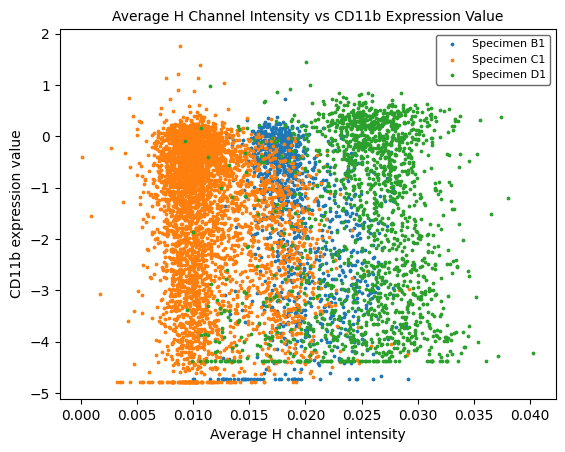

In [13]:
plt.figure()
ax = plt.gca()

ax.scatter(average_hs[b_indices], cd11b_values[b_indices], s=3, label='Specimen B1')
ax.scatter(average_hs[c_indices], cd11b_values[c_indices], s=3, label='Specimen C1')
ax.scatter(average_hs[d_indices], cd11b_values[d_indices], s=3, label='Specimen D1')
ax.set_xlabel('Average H channel intensity')
ax.set_ylabel('CD11b expression value')
ax.set_title('Average H Channel Intensity vs CD11b Expression Value', fontsize=10)

frame = plt.legend(fontsize=8, frameon=True).get_frame()
frame.set_edgecolor('#444444')

In [14]:
from scipy.stats import spearmanr, pearsonr

print(spearmanr(average_hs, cd11b_values).statistic)
print(pearsonr(average_hs, cd11b_values).statistic)

-0.05841380665141695
-0.07349653751906055


There is a very weak negative correlation between the H-channel intensity and the CD11b expression. H-channel intensity is unlikely to have much predictive power for CD11b expression. It explains very little variance in the expression. 

0.2288638686327423
0.27776240426021365


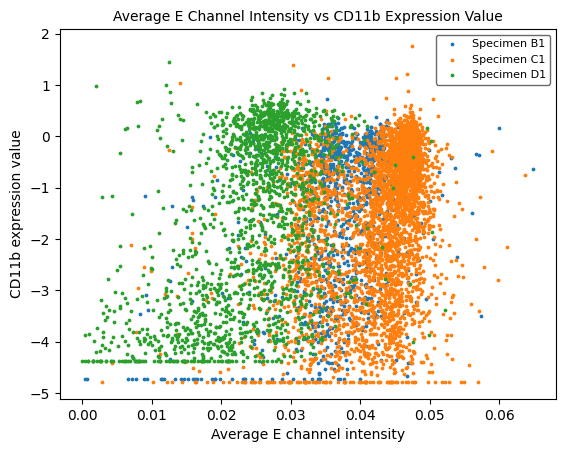

In [15]:
plt.figure()
ax = plt.gca()

ax.scatter(average_es[b_indices], cd11b_values[b_indices], s=3, label='Specimen B1')
ax.scatter(average_es[c_indices], cd11b_values[c_indices], s=3, label='Specimen C1')
ax.scatter(average_es[d_indices], cd11b_values[d_indices], s=3, label='Specimen D1')
ax.set_xlabel('Average E channel intensity')
ax.set_ylabel('CD11b expression value')
ax.set_title('Average E Channel Intensity vs CD11b Expression Value', fontsize=10)

frame = plt.legend(fontsize=8, frameon=True).get_frame()
frame.set_edgecolor('#444444')

print(spearmanr(average_es, cd11b_values).statistic)
print(pearsonr(average_es, cd11b_values).statistic)

There is a weak, but stronger, positive correlation between the E channel and the CD11b expression value. The E channel average may help to predict the CD11b expression. However, there is still a lot of unexplained variance. 

## v) Blue vs H Channels

0.3878013601645221
0.367405687588898


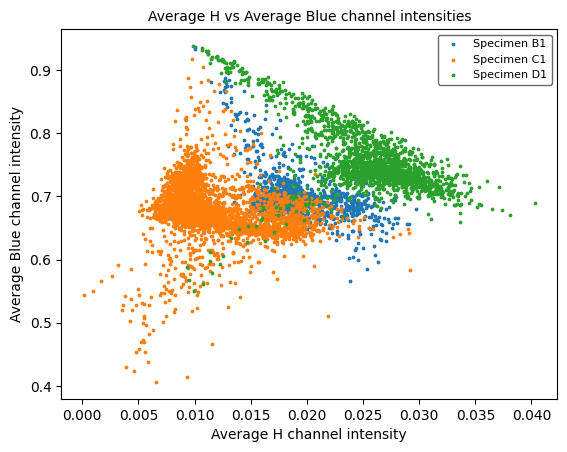

In [16]:
plt.figure()
ax = plt.gca()

ax.scatter(average_hs[b_indices], average_bs[b_indices], s=3, label='Specimen B1')
ax.scatter(average_hs[c_indices], average_bs[c_indices], s=3, label='Specimen C1')
ax.scatter(average_hs[d_indices], average_bs[d_indices], s=3, label='Specimen D1')
ax.set_xlabel('Average H channel intensity')
ax.set_ylabel('Average Blue channel intensity')
ax.set_title('Average H vs Average Blue channel intensities', fontsize=10)

frame = plt.legend(fontsize=8, frameon=True).get_frame()
frame.set_edgecolor('#444444')

print(spearmanr(average_hs, average_bs).statistic)
print(pearsonr(average_hs, average_bs).statistic)

We can see that the H channel is able to partially separate out the three specimens, whereas the blue channel is much less able to do this. We can also see that there is some correlation between the H and Blue channels, but it is highly non-linear, which is due to the fact that the H channel is also influenced by the red and green channels. However, we can see that there are limits as to what blue values can be converted to what H values, and the shape roughly appears triangular in the scatter diagram. For example, there are no examples where an average blue channel of 0.9 correlates to an average H channel of 0.3. 

We can check for association between protein expression levels by finding the pairwise correlations of each. You can see the result below, with red colours indicating a higher correlation between the proteins. It is evident that there is association between protein expression levels of some pairs of proteins. For example, MET and PDGFRa are quite positively correlated. In fact, the correlations are mostly positvie. There are some pairs that are weakly negatively correlated. 

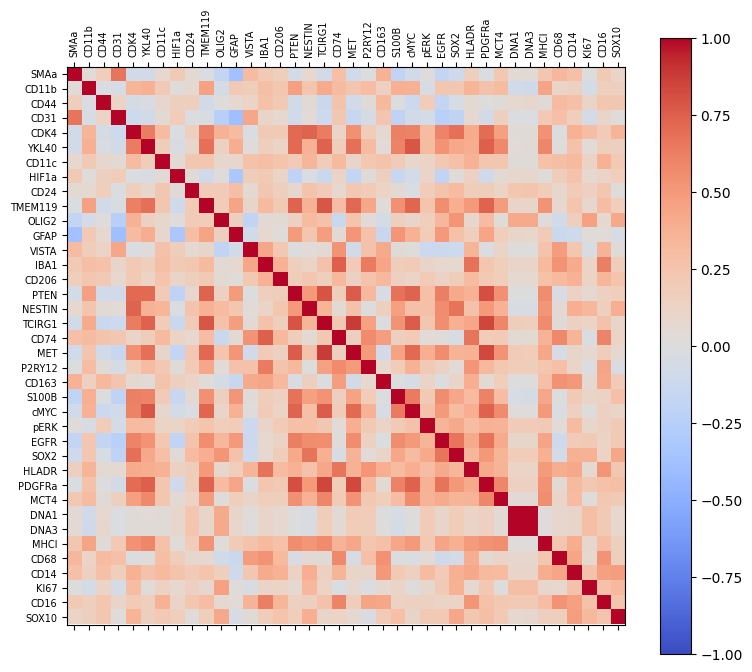

In [17]:
corr = df_train[protein_names].corr()

plt.figure(figsize=[9, 8])
ax = plt.gca()
corr_ax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(corr_ax)
ticks = np.arange(0, len(protein_names))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(protein_names, fontsize=7, rotation=90)
ax.set_yticklabels(protein_names, fontsize=7);

# Question 2

## i) Feature Selection 

### PCA On all RGB Channels

In [18]:
from sklearn.decomposition import PCA

width, height = list(training_images.values())[0].shape[:2]

X = np.array(list(training_images.values()))
X_HED = np.zeros_like(X)
for i in range(X.shape[0]):
    X_HED[i] = rgb2hed(X[i])

(0.0, 1.0)

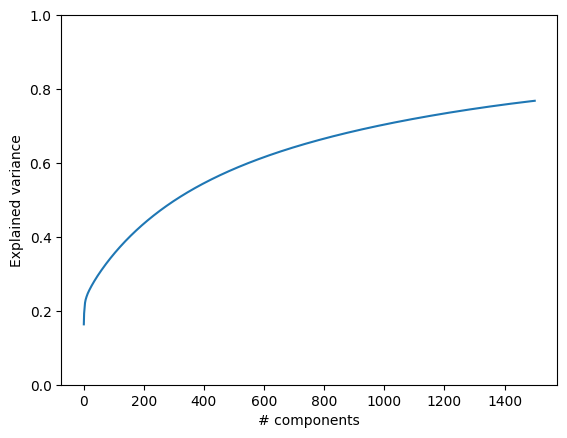

In [ ]:
"""
X = X.reshape((X.shape[0], -1))

pca = PCA(1500)
pca.fit(X)

plt.plot(np.arange(1, pca.n_components_ + 1), np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('# components')
plt.ylabel('Explained variance')
plt.ylim([0, 1])"""

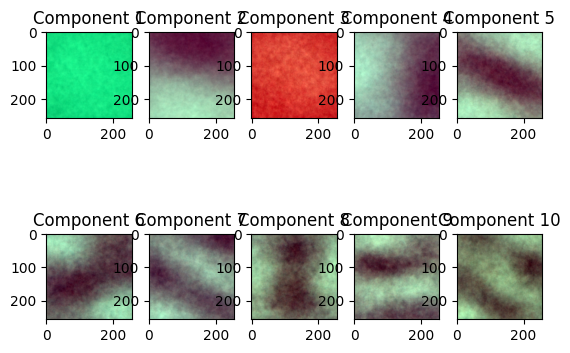

In [19]:
i = 0
for c in pca.components_[:10]:
    c = (c - np.min(c)) / (np.max(c) - np.min(c))
    c = c.reshape((width, height, 3))
    
    plt.subplot(2, 5, i+1)
    plt.imshow(c)
    plt.title(f"Component {i+1}")
    i += 1

Using the first image as an example

KeyboardInterrupt: 

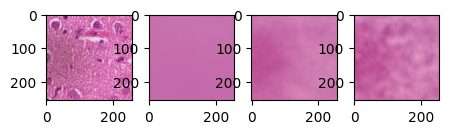

In [ ]:
"""

num_components = [2, 25, 100, 1500]

plt.subplot(1, 5, 1)
I = training_images[list(training_images.keys())[0]]
plt.imshow(I)

for i in range(len(num_components)):
    n = num_components[i]
    pca = PCA(n)
    pca.fit(X)
    Z = pca.transform(I.reshape((1, -1)))
    R = pca.inverse_transform(Z)

    R = R.reshape((height, width, 3))
    plt.subplot(1,5,i+2)
    plt.imshow(R)"""


### PCA on all HED channels

(7027, 196608)


(0.0, 1.0)

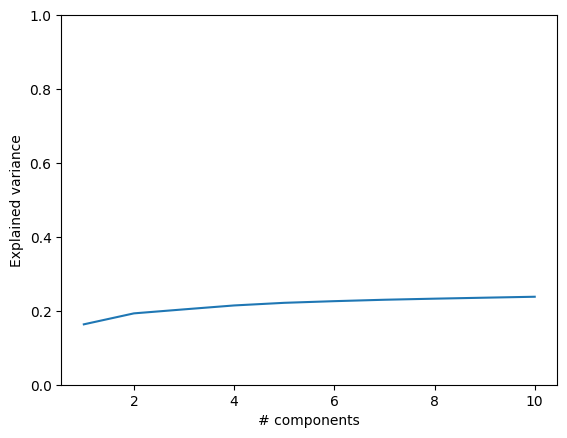

In [28]:
for i in range(X.shape[0]):
    X[i] = rgb2hed(X[i])


X = X.reshape((X.shape[0], -1))

# X = X.reshape((X.shape[0], -1))

print(X.shape)

pca = PCA(10)
pcs = pca.fit_transform(X)

plt.plot(np.arange(1, pca.n_components_ + 1), np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('# components')
plt.ylabel('Explained variance')
plt.ylim([0, 1])



Explained variance for RGB and HED look very similar. 

     PC  Pearson Correlation
0   PC1             0.017554
6   PC7             0.011405
2   PC3             0.006507
3   PC4             0.005272
9  PC10             0.003083
5   PC6            -0.001457
1   PC2            -0.003027
8   PC9            -0.006612
7   PC8            -0.007437
4   PC5            -0.010118


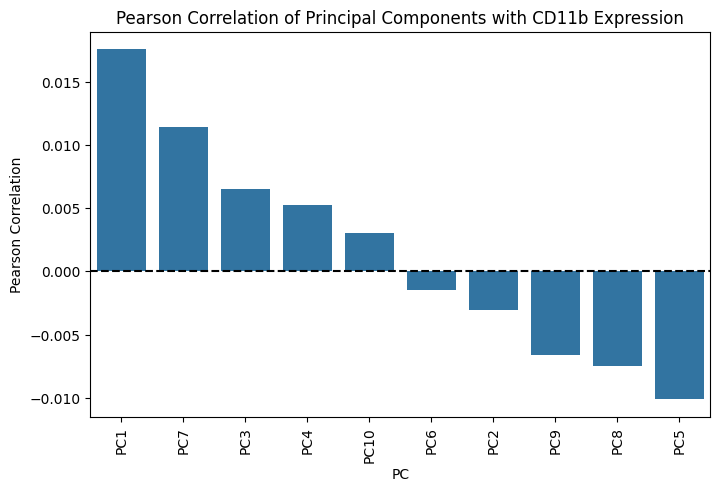

In [42]:
pc_df = pd.DataFrame(pcs, columns=[f"PC{i+1}" for i in range(pca.n_components_)])

# Compute Spearman correlation
pearson_corr = {col: pearsonr(pc_df[col], df_train['CD11b']).statistic for col in pc_df.columns}

# Convert to DataFrame for visualization
pearson_df = pd.DataFrame(list(pearson_corr.items()), columns=["PC", "Pearson Correlation"]).sort_values("Pearson Correlation", ascending=False)
print(pearson_df)

# Plot results
plt.figure(figsize=(8, 5))
sns.barplot(x=pearson_df["PC"], y=pearson_df["Pearson Correlation"])
plt.axhline(0, color='black', linestyle='dashed')
plt.xticks(rotation=90)
plt.ylabel("Pearson Correlation")
plt.title("Pearson Correlation of Principal Components with CD11b Expression")
plt.show()

     PC  Spearman Correlation
0   PC1              0.026078
3   PC4              0.016537
6   PC7              0.016127
8   PC9              0.001320
1   PC2              0.000252
5   PC6             -0.002602
2   PC3             -0.005860
9  PC10             -0.007412
7   PC8             -0.009387
4   PC5             -0.009859


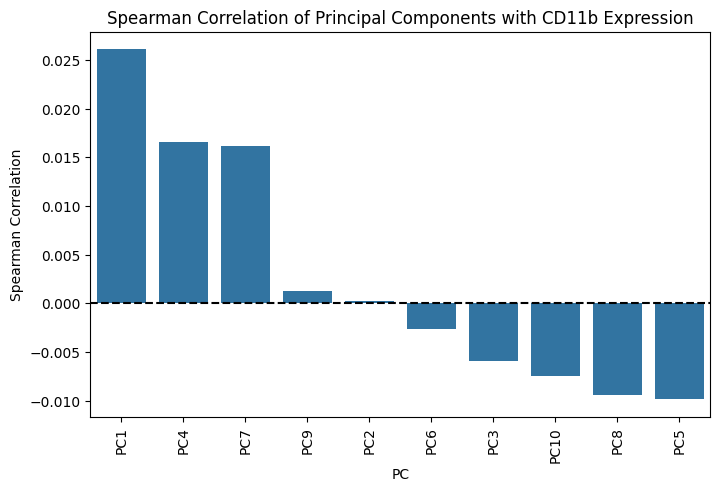

In [43]:
# Compute Spearman correlation
spearman_corr = {col: spearmanr(pc_df[col], df_train['CD11b']).statistic for col in pc_df.columns}

# Convert to DataFrame for visualization
spearman_df = pd.DataFrame(list(spearman_corr.items()), columns=["PC", "Spearman Correlation"]).sort_values("Spearman Correlation", ascending=False)
print(spearman_df)

# Plot results
plt.figure(figsize=(8, 5))
sns.barplot(x=spearman_df["PC"], y=spearman_df["Spearman Correlation"])
plt.axhline(0, color='black', linestyle='dashed')
plt.xticks(rotation=90)
plt.ylabel("Spearman Correlation")
plt.title("Spearman Correlation of Principal Components with CD11b Expression")
plt.show()

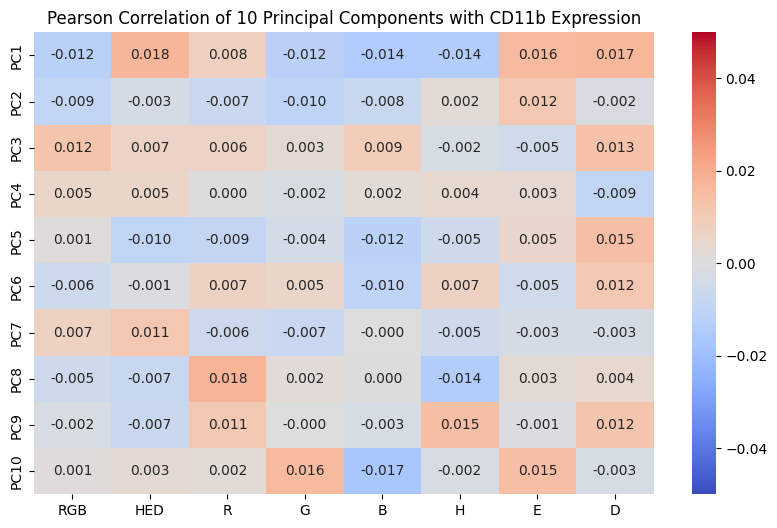

In [35]:
# Set number of principal components to keep
n_components = 10  # Change this to any desired number of PCs

# Flatten each image into a vector for PCA
X_rgb_flat = X.reshape(n_train, -1)  # All RGB channels
X_hed_flat = X_HED.reshape(n_train, -1)  # All HED channels
X_r_flat = X[..., 0].reshape(n_train, -1)  # Red channel only
X_g_flat = X[..., 1].reshape(n_train, -1)  # Green channel only
X_b_flat = X[..., 2].reshape(n_train, -1)  # Blue channel only
X_h_flat = X_HED[..., 0].reshape(n_train, -1)  # H channel only
X_e_flat = X_HED[..., 1].reshape(n_train, -1)  # E channel only
X_d_flat = X_HED[..., 2].reshape(n_train, -1)  # D channel only

# Perform PCA with a variable number of components
def apply_pca(X_flat):
    return PCA(n_components=n_components).fit_transform(X_flat)

pca_results = {
    "RGB": apply_pca(X_rgb_flat),
    "HED": apply_pca(X_hed_flat),
    "R": apply_pca(X_r_flat),
    "G": apply_pca(X_g_flat),
    "B": apply_pca(X_b_flat),
    "H": apply_pca(X_h_flat),
    "E": apply_pca(X_e_flat),
    "D": apply_pca(X_d_flat),
}

# Compute Pearson correlation with CD11b expression
def compute_pearson(pca_result):
    return [np.corrcoef(pca_result[:, i], df_train["CD11b"])[0, 1] for i in range(pca_result.shape[1])]

correlations = {key: compute_pearson(pca) for key, pca in pca_results.items()}

# Convert to DataFrame
df_corr = pd.DataFrame(correlations, index=[f"PC{i+1}" for i in range(n_components)])

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", center=0, fmt=".3f", vmin=-0.05, vmax=0.05)
plt.title(f"Pearson Correlation of {n_components} Principal Components with CD11b Expression")
plt.show()

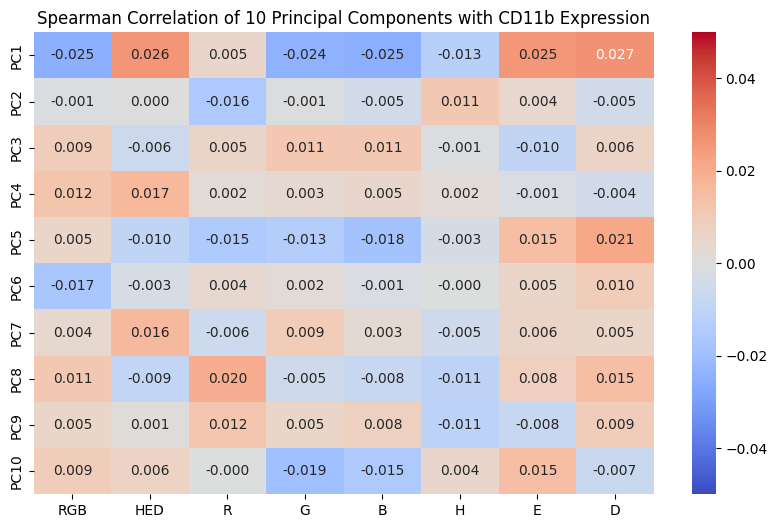

In [34]:
# Compute Pearson correlation with CD11b expression
def compute_spearman(pca_result):
    return [spearmanr(pca_result[:, i], df_train["CD11b"])[0] for i in range(pca_result.shape[1])]

correlations = {key: compute_spearman(pca) for key, pca in pca_results.items()}

# Convert to DataFrame
df_corr = pd.DataFrame(correlations, index=[f"PC{i+1}" for i in range(n_components)])

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", center=0, fmt=".3f", vmin=-0.05, vmax=0.05)
plt.title(f"Spearman Correlation of {n_components} Principal Components with CD11b Expression")
plt.show()

### Mean and Variance

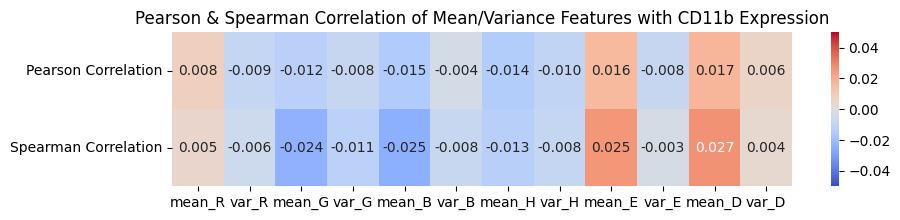

In [33]:
features = {
    "mean_R": np.mean(X[..., 0], axis=(1, 2)),  # Mean of Red channel
    "var_R": np.var(X[..., 0], axis=(1, 2)),    # Variance of Red channel
    "mean_G": np.mean(X[..., 1], axis=(1, 2)),  # Green
    "var_G": np.var(X[..., 1], axis=(1, 2)),    
    "mean_B": np.mean(X[..., 2], axis=(1, 2)),  # Blue
    "var_B": np.var(X[..., 2], axis=(1, 2)),    
    "mean_H": np.mean(X_HED[..., 0], axis=(1, 2)),   # H
    "var_H": np.var(X_HED[..., 0], axis=(1, 2)),
    "mean_E": np.mean(X_HED[..., 1], axis=(1, 2)),   # E
    "var_E": np.var(X_HED[..., 1], axis=(1, 2)),
    "mean_D": np.mean(X_HED[..., 2], axis=(1, 2)),   # D
    "var_D": np.var(X_HED[..., 2], axis=(1, 2)),
}

# Convert to DataFrame
df_features = pd.DataFrame(features)

# Compute Pearson correlation with CD11b
pearson_corr = df_features.apply(lambda x: pearsonr(x, df_train["CD11b"]).correlation).to_frame(name="Pearson Correlation")
spearman_corr = df_features.apply(lambda x: spearmanr(x, df_train["CD11b"]).correlation).to_frame(name="Spearman Correlation")

# Combine both Pearson and Spearman correlation results
df_corr = pd.concat([pearson_corr, spearman_corr], axis=1)

# Reshape to table format (transpose for better readability)
df_corr_table = df_corr.T

# Plot heatmap
color_scale = 0.05  # Adjust for better visualization
plt.figure(figsize=(10, 2))
sns.heatmap(df_corr_table, annot=True, cmap="coolwarm", center=0, fmt=".3f", vmin=-color_scale, vmax=color_scale)
plt.title("Pearson & Spearman Correlation of Mean/Variance Features with CD11b Expression")
plt.show()